<a href="https://colab.research.google.com/github/brunopn-code/bank-marketing-propensity/blob/main/notebooks/02_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("bank_marketing_clean.csv")

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

-----

## Target Distribution

Before analyzing client and campaign variables, we first inspect the target variable.

The target variable `y` indicates whether the client subscribed to a term deposit. Since marketing campaign datasets are often imbalanced, checking the proportion of positive and negative responses is important before modeling.

In [5]:
target_counts = df["y"].value_counts()
target_rates = df["y"].value_counts(normalize=True).round(4) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_rates
})

target_summary

,count,percentage
y,,
no,36548,88.73
yes,4640,11.27


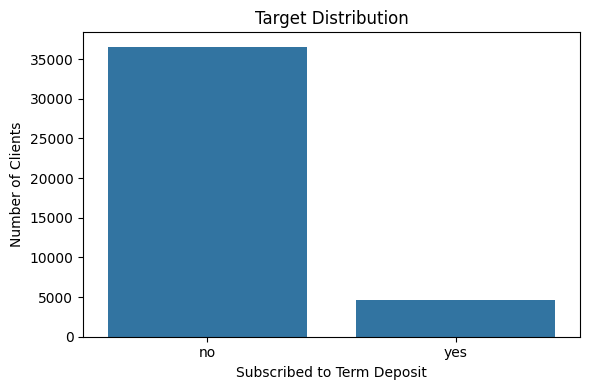

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Target Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()

#Target distribution findings

The dataset is imbalanced. Most clients did not subscribe to the term deposit, while only a smaller percentage subscribed.

This means that accuracy alone will not be enough to evaluate the machine learning models. A model could achieve high accuracy by mostly predicting the majority class. For this reason, as said in the previous notebook, the modeling stage should also use precision, recall, F1-score, ROC-AUC, and confusion matrix.

------

## Subscription Rate by Client Profile

Next, we analyze whether subscription rates differ across client characteristics such as job, education, marital status, and age.

This helps identify which types of clients appear more likely to subscribe to a term deposit.

In [7]:
#function to create an aggregate by variables
def subscription_rate_by_category(df, column):
    summary = (
        df.groupby(column)
        .agg(
            total_clients=("target", "count"),
            subscribed_clients=("target", "sum"),
            subscription_rate=("target", "mean")
        )
        .reset_index()
    )

    summary["subscription_rate"] = (summary["subscription_rate"] * 100).round(2)

    return summary.sort_values("subscription_rate", ascending=False)

In [8]:
job_subscription = subscription_rate_by_category(df, "job")
job_subscription

,job,total_clients,subscribed_clients,subscription_rate
8,student,875,275,31.43
5,retired,1720,434,25.23
10,unemployed,1014,144,14.20
0,admin.,10422,1352,12.97
4,management,2924,328,11.22
11,unknown,330,37,11.21
9,technician,6743,730,10.83
6,self-employed,1421,149,10.49
3,housemaid,1060,106,10.00
2,entrepreneur,1456,124,8.52


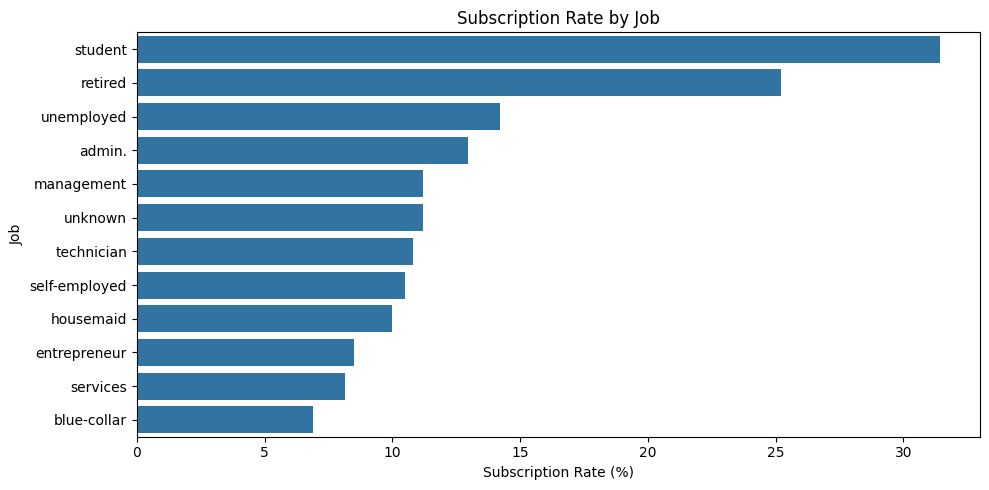

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=job_subscription,
    x="subscription_rate",
    y="job"
)
plt.title("Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_job.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
education_subscription = subscription_rate_by_category(df, "education")
education_subscription

,education,total_clients,subscribed_clients,subscription_rate
4,illiterate,18,4,22.22
7,unknown,1731,251,14.50
6,university.degree,12168,1670,13.72
5,professional.course,5243,595,11.35
3,high.school,9515,1031,10.84
0,basic.4y,4176,428,10.25
1,basic.6y,2292,188,8.20
2,basic.9y,6045,473,7.82


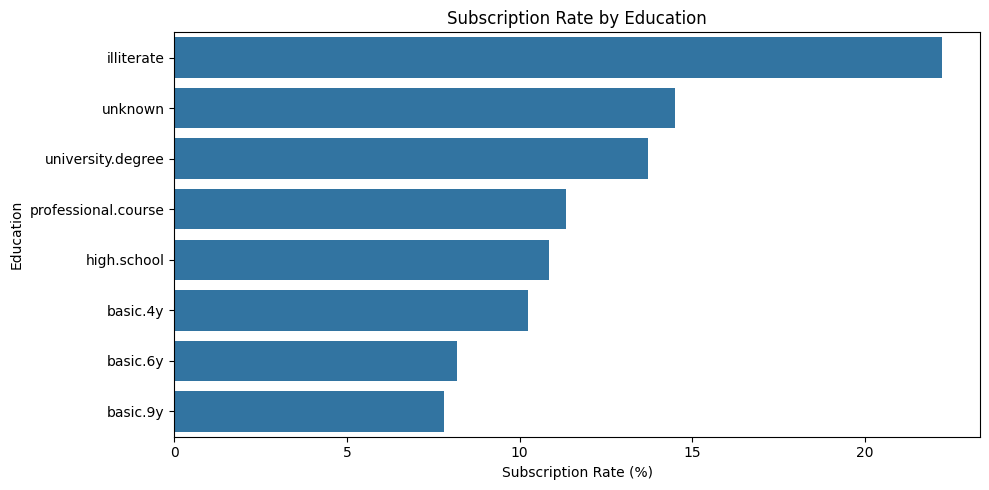

In [56]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=education_subscription,
    x="subscription_rate",
    y="education"
)
plt.title("Subscription Rate by Education")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Education")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_education.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
marital_subscription = subscription_rate_by_category(df, "marital")
marital_subscription

,marital,total_clients,subscribed_clients,subscription_rate
3,unknown,80,12,15.00
2,single,11568,1620,14.00
0,divorced,4612,476,10.32
1,married,24928,2532,10.16


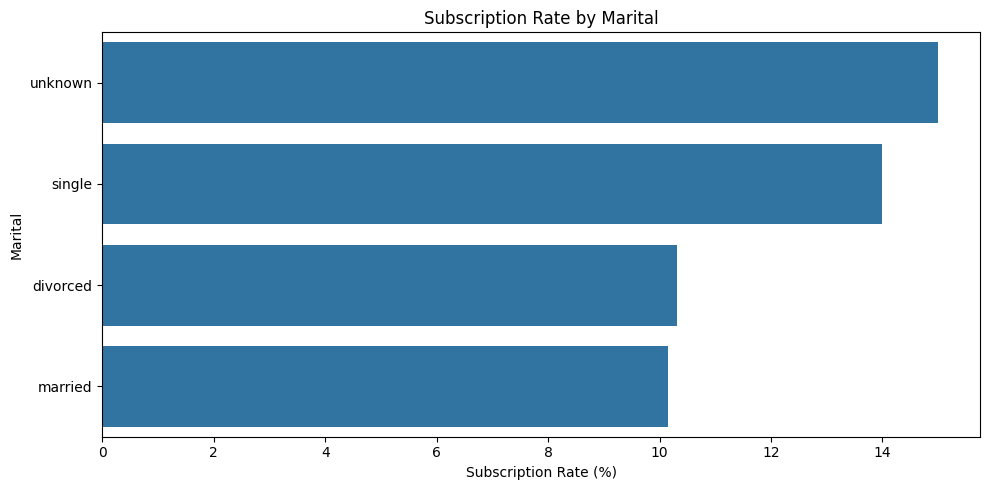

In [57]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=marital_subscription,
    x="subscription_rate",
    y="marital"
)
plt.title("Subscription Rate by Marital")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Marital")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_marital.png", dpi=300, bbox_inches="tight")
plt.show()

### Client Profile Findings

Subscription rates vary noticeably across client profile groups.

By job, `student` clients have the highest subscription rate at 31.43%, followed by `retired` clients at 25.23%. In contrast, `blue-collar` clients have the lowest subscription rate at 6.89%, followed by `services` at 8.14% and `entrepreneur` at 8.52%.

By education, `university.degree` clients have a higher subscription rate than most basic education groups. The `illiterate` category shows a high subscription rate, but it contains only 18 clients, so it should not be interpreted as a reliable pattern.

By marital status, `single` clients have a higher subscription rate than married and divorced clients. The `unknown` marital category also has a higher rate, but it contains only 80 clients, so it should be interpreted carefully.

Overall, these results suggest that client profile variables such as job, education, and marital status are associated with subscription behavior. These relationships should be examined further during the modeling phase using statistical association analysis and feature importance methods.


------

## Age Distribution

Before creating age groups, we first inspect the distribution of the `age` variable.

This helps avoid defining arbitrary age ranges without understanding the actual spread of the data. Summary statistics, a histogram, and boxplots are used to identify the typical age range, median age, variation, and possible outliers.

Older clients should not be removed automatically, because they may represent valid customer segments and could be relevant for subscription behavior.


In [14]:
df["age"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,age
count,41188.00000
mean,40.02406
std,10.42125
min,17.00000
1%,23.00000
5%,26.00000
25%,32.00000
50%,38.00000
75%,47.00000
95%,58.00000


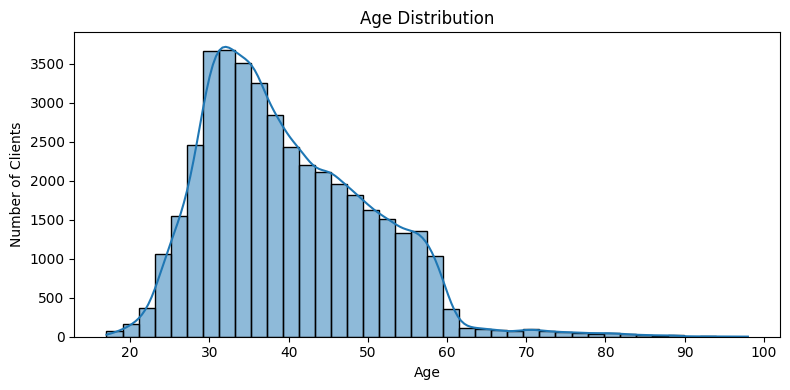

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="age", bins=40, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.savefig("eda_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

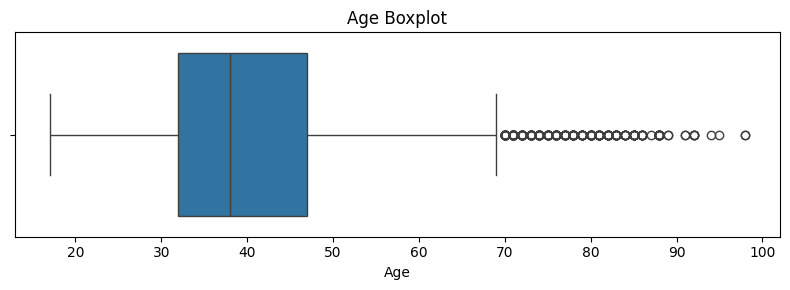

In [16]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x="age")
plt.title("Age Boxplot")
plt.xlabel("Age")
plt.tight_layout()
plt.savefig("eda_age_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Age Distribution Findings

The age distribution is right-skewed, with most clients concentrated between their early 30s and late 40s. The median age is 38, and 75% of clients are 47 years old or younger.

There is a smaller group of older clients, with values above 70 appearing as outliers in the boxplot. These observations should not be removed automatically because they are valid client records and may represent an important customer segment.

Based on the distribution, age groups were created to separate younger clients, the main working-age population, and older clients.


In [17]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 40, 50, 60, 70, 100],
    labels=["Under 30", "30-39", "40-49", "50-59", "60-69", "70+"],
    right=False
)

In [18]:
df["age_group"].value_counts().sort_index()

,count
age_group,
Under 30,5669
30-39,16938
40-49,10526
50-59,6862
60-69,724
70+,469


In [19]:
age_subscription = subscription_rate_by_category(df, "age_group")
age_subscription

/tmp/ipykernel_926/904224103.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(column)


,age_group,total_clients,subscribed_clients,subscription_rate
5,70+,469,221,47.12
4,60-69,724,251,34.67
0,Under 30,5669,922,16.26
3,50-59,6862,697,10.16
1,30-39,16938,1715,10.13
2,40-49,10526,834,7.92


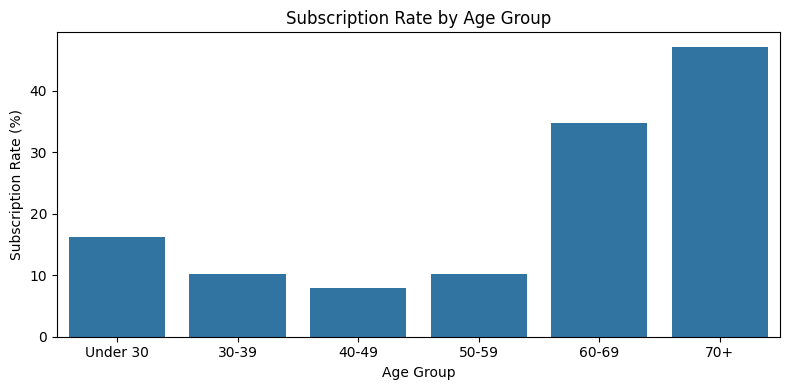

In [20]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=age_subscription.sort_values("age_group"),
    x="age_group",
    y="subscription_rate"
)
plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

### Age Group Findings

Subscription rates vary strongly by age group.

Clients aged `70+` have the highest subscription rate at 47.12%, followed by clients aged `60-69` at 34.67%. Younger clients under 30 also show a higher-than-average subscription rate at 16.26%.

In contrast, the main working-age groups between 30 and 59 have lower subscription rates, especially the `40-49` group, which has the lowest subscription rate at 7.92%.

Together with the job-based analysis, this suggests that students and retired clients are more likely to subscribe than the main working-age population. This should be interpreted as an association rather than a causal conclusion, because age and job are related variables and may interact with other campaign and economic factors.

-----

## Campaign and Contact Variables

After analyzing client profile variables, we now examine campaign-related variables.

These features describe how the client was contacted, when the contact happened, how many contacts were made during the campaign, and whether the client had previous campaign interactions.

This section helps identify marketing conditions associated with higher subscription rates.


In [21]:
contact_subscription = subscription_rate_by_category(df, "contact")
contact_subscription

,contact,total_clients,subscribed_clients,subscription_rate
0,cellular,26144,3853,14.74
1,telephone,15044,787,5.23


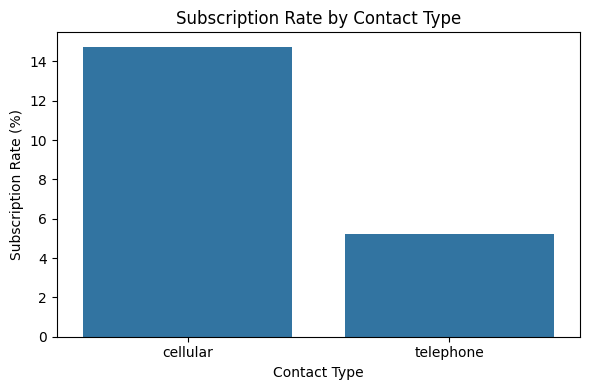

In [22]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=contact_subscription,
    x="contact",
    y="subscription_rate"
)
plt.title("Subscription Rate by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_contact.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
month_subscription = subscription_rate_by_category(df, "month")
month_subscription

,month,total_clients,subscribed_clients,subscription_rate
5,mar,546,276,50.55
2,dec,182,89,48.90
9,sep,570,256,44.91
8,oct,718,315,43.87
0,apr,2632,539,20.48
1,aug,6178,655,10.60
4,jun,5318,559,10.51
7,nov,4101,416,10.14
3,jul,7174,649,9.05
6,may,13769,886,6.43


In [24]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

month_subscription["month"] = pd.Categorical(
    month_subscription["month"],
    categories=month_order,
    ordered=True
)

month_subscription = month_subscription.sort_values("month")

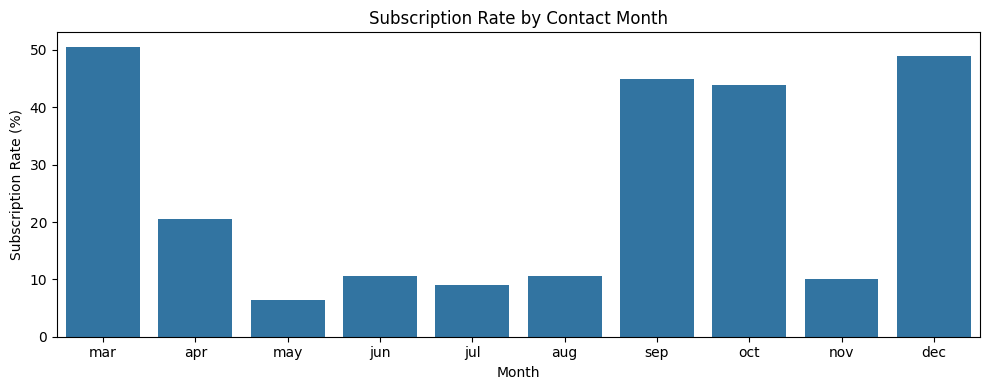

In [25]:
plt.figure(figsize=(10, 4))
sns.barplot(
    data=month_subscription,
    x="month",
    y="subscription_rate"
)
plt.title("Subscription Rate by Contact Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_month.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
poutcome_subscription = subscription_rate_by_category(df, "poutcome")
poutcome_subscription

,poutcome,total_clients,subscribed_clients,subscription_rate
2,success,1373,894,65.11
0,failure,4252,605,14.23
1,nonexistent,35563,3141,8.83


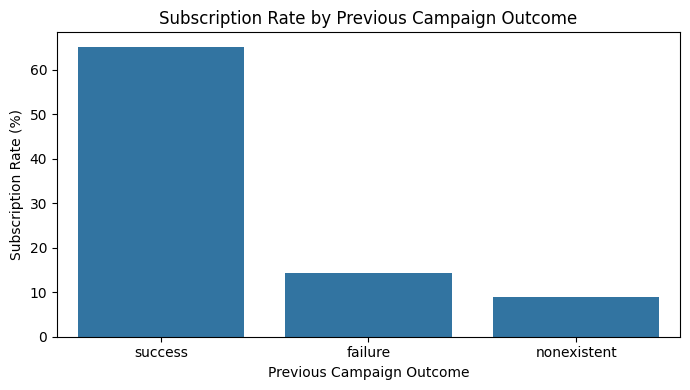

In [27]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=poutcome_subscription,
    x="poutcome",
    y="subscription_rate"
)
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_poutcome.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
df["campaign"].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

,campaign
count,41188.000000
mean,2.567593
std,2.770014
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
90%,5.000000
95%,7.000000
99%,14.000000


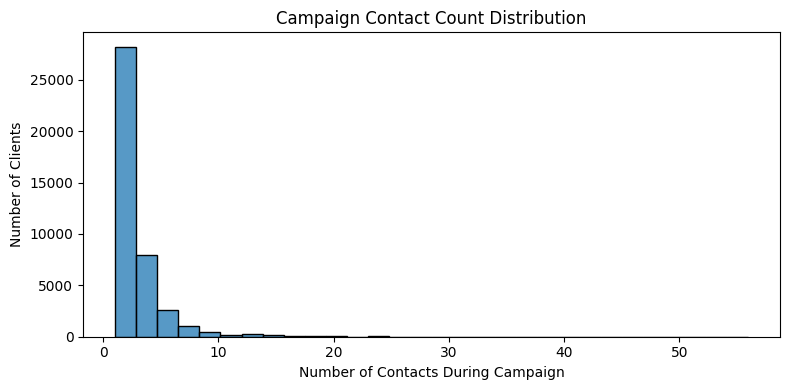

In [29]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="campaign", bins=30)
plt.title("Campaign Contact Count Distribution")
plt.xlabel("Number of Contacts During Campaign")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.savefig("eda_campaign_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

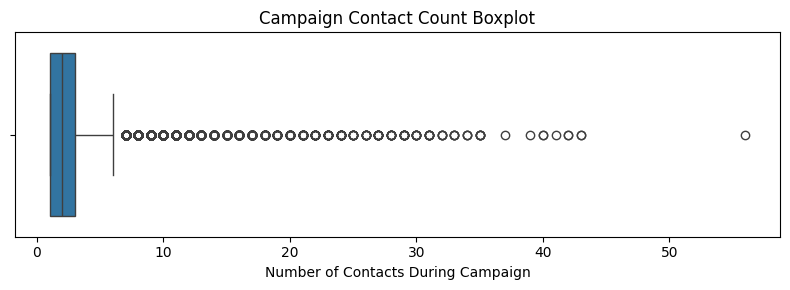

In [30]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x="campaign")
plt.title("Campaign Contact Count Boxplot")
plt.xlabel("Number of Contacts During Campaign")
plt.tight_layout()
plt.savefig("eda_campaign_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=[0, 1, 2, 3, 5, 14, 100],
    labels=["1 contact", "2 contacts", "3 contacts", "4-5 contacts", "6-14 contacts", "14+ contacts"],
    right=True
)

In [32]:
campaign_subscription = subscription_rate_by_category(df, "campaign_group")
campaign_subscription

/tmp/ipykernel_926/904224103.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(column)


,campaign_group,total_clients,subscribed_clients,subscription_rate
0,1 contact,17642,2300,13.04
1,2 contacts,10570,1211,11.46
2,3 contacts,5341,574,10.75
3,4-5 contacts,4250,369,8.68
4,6-14 contacts,2979,179,6.01
5,14+ contacts,406,7,1.72


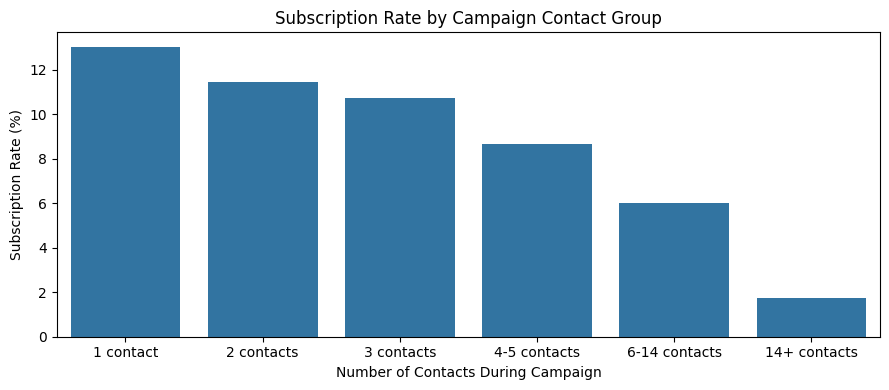

In [33]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=campaign_subscription.sort_values("campaign_group"),
    x="campaign_group",
    y="subscription_rate"
)
plt.title("Subscription Rate by Campaign Contact Group")
plt.xlabel("Number of Contacts During Campaign")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_campaign_group.png", dpi=300, bbox_inches="tight")
plt.show()

### Campaign and Contact Variable Findings

Campaign-related variables show clear differences in subscription rates.

Clients contacted by `cellular` have a higher subscription rate than clients contacted by `telephone`. This suggests that contact channel may be associated with campaign success.

Previous campaign outcome also shows a strong relationship with subscription. Clients with a previous campaign outcome of `success` have a much higher subscription rate than clients with `failure` or `nonexistent` previous outcomes. This suggests that past positive engagement is an important signal for future subscription behavior.

Subscription rates also vary strongly by month. The months `mar`, `dec`, `sep`, and `oct` show the highest subscription rates. However, these months contain fewer clients than high-volume months such as `may`, so this pattern should be interpreted carefully.

The number of campaign contacts shows an inverse relationship with subscription rate. Clients contacted once have the highest subscription rate, while clients contacted many times have much lower subscription rates. This may indicate that repeated contact attempts are associated with lower conversion probability. However, this should not be interpreted as a direct causal effect, because clients who are harder to convert may naturally receive more contact attempts.

Overall, these results suggest that contact type, contact month, previous campaign outcome, and number of campaign contacts are associated with subscription behavior. These relationships should be examined further using statistical association tests and model-based feature importance during the modeling phase.


-----

## Contact Duration Analysis

The variable `duration` represents the duration of the last contact with the client, measured in seconds.

This variable is important because it is likely to be strongly associated with subscription. Longer calls may indicate greater client interest or more detailed conversations.

However, `duration` is only known after the contact has already happened. Therefore, it should not be used in a realistic pre-campaign targeting model, because the goal is to predict which clients to contact before the campaign.

For this reason, the modeling phase will compare two approaches:

1. a model including `duration`
2. a realistic model excluding `duration`


In [34]:
df["duration"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

,duration
count,41188.000000
mean,258.285010
std,259.279249
min,0.000000
1%,11.000000
5%,36.000000
25%,102.000000
50%,180.000000
75%,319.000000
90%,551.000000


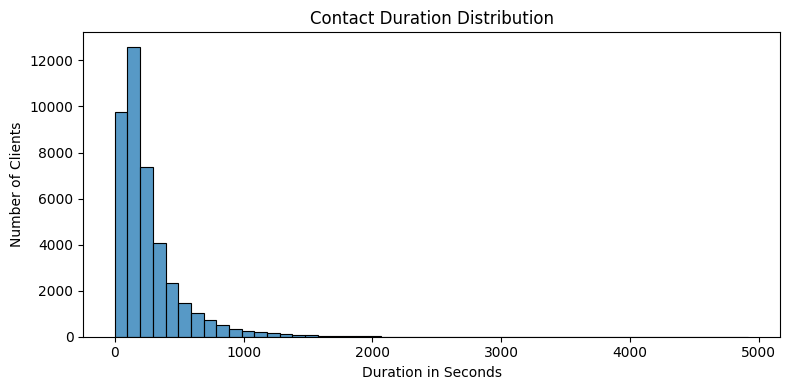

In [35]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="duration", bins=50)
plt.title("Contact Duration Distribution")
plt.xlabel("Duration in Seconds")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.savefig("eda_duration_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

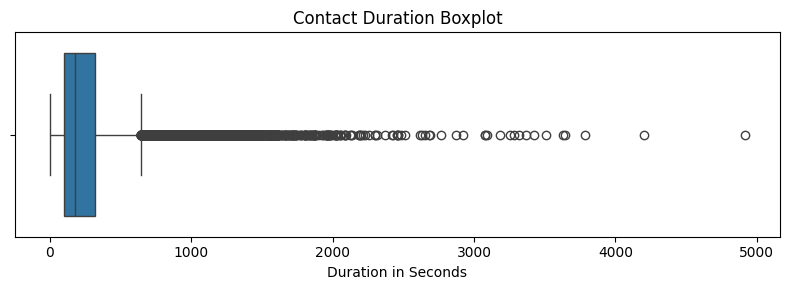

In [36]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x="duration")
plt.title("Contact Duration Boxplot")
plt.xlabel("Duration in Seconds")
plt.tight_layout()
plt.savefig("eda_duration_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
duration_by_target = (
    df.groupby("y")["duration"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
)

duration_by_target

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
y,,,,,,,,,,,
no,36548.0,220.844807,207.096293,0.0,95.0,163.5,279.00,447.0,595.0,1018.53,4918.0
yes,4640.0,553.191164,401.171871,37.0,253.0,449.0,741.25,1070.1,1311.0,1880.05,4199.0


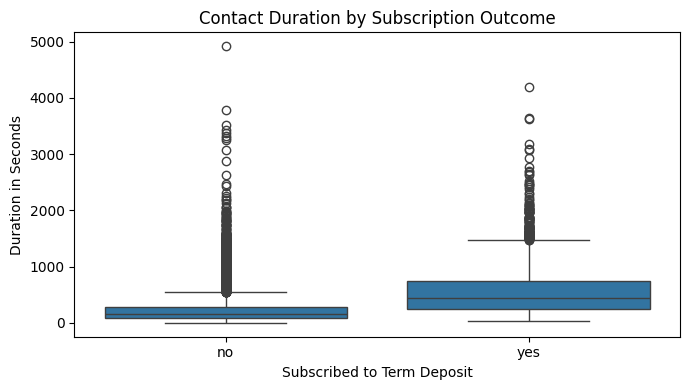

In [38]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="y", y="duration")
plt.title("Contact Duration by Subscription Outcome")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Duration in Seconds")
plt.tight_layout()
plt.savefig("eda_duration_by_subscription_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
df["duration_group"] = pd.cut(
    df["duration"],
    bins=[-1, 60, 180, 300, 600, 1200, df["duration"].max()],
    labels=[
        "0-1 min",
        "1-3 min",
        "3-5 min",
        "5-10 min",
        "10-20 min",
        "20+ min"
    ]
)

In [40]:
duration_subscription = subscription_rate_by_category(df, "duration_group")
duration_subscription

/tmp/ipykernel_926/904224103.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(column)


,duration_group,total_clients,subscribed_clients,subscription_rate
5,20+ min,513,321,62.57
4,10-20 min,2951,1363,46.19
3,5-10 min,7740,1438,18.58
2,3-5 min,9279,954,10.28
1,1-3 min,16419,563,3.43
0,0-1 min,4286,1,0.02


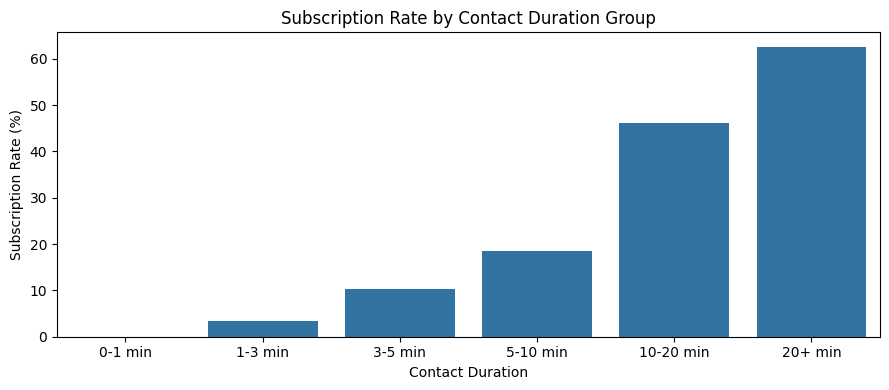

In [41]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=duration_subscription.sort_values("duration_group"),
    x="duration_group",
    y="subscription_rate"
)
plt.title("Subscription Rate by Contact Duration Group")
plt.xlabel("Contact Duration")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_duration_group.png", dpi=300, bbox_inches="tight")
plt.show()

### Contact Duration Findings

Contact duration shows a very strong relationship with subscription.

Clients who subscribed had much longer calls on average than clients who did not subscribe. The median duration for non-subscribers was 163.5 seconds, while the median duration for subscribers was 449.0 seconds.

Subscription rates also increase sharply across duration groups. Calls shorter than one minute almost never resulted in subscription, while calls longer than 10 minutes had much higher subscription rates.

This suggests that longer conversations are strongly associated with positive campaign outcomes. However, `duration` is a data leakage risk because it is only known after the client has already been contacted. For a realistic pre-campaign targeting model, this variable should be excluded.

AS said previously, because of this, the modeling phase should compare two versions:

1. A model including `duration`, useful as a performance upper bound.
2. A realistic model excluding `duration`, useful for predicting which clients to contact before the campaign.


----

## Economic Context Variables

The dataset includes macroeconomic and social context variables collected around the time of the campaign.

These variables may help explain why subscription rates differ across months and campaign periods. Instead of only looking at client characteristics, this section checks whether broader economic conditions are associated with subscription behavior.

The variables analyzed are:

* `emp_var_rate`: employment variation rate
* `cons_price_idx`: consumer price index
* `cons_conf_idx`: consumer confidence index
* `euribor3m`: 3-month Euribor rate
* `nr_employed`: number of employees


In [42]:
economic_features = [
    "emp_var_rate",
    "cons_price_idx",
    "cons_conf_idx",
    "euribor3m",
    "nr_employed"
]

df[economic_features].describe()

,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,1.570960,0.578840,4.628198,1.734447,72.251528
min,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [43]:
economic_by_target = df.groupby("y")[economic_features].mean().round(3)
economic_by_target

,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
y,,,,,
no,0.249,93.604,-40.593,3.811,5176.167
yes,-1.233,93.354,-39.790,2.123,5095.116


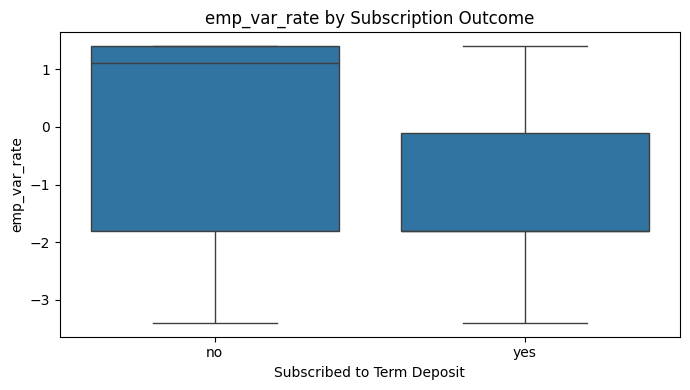

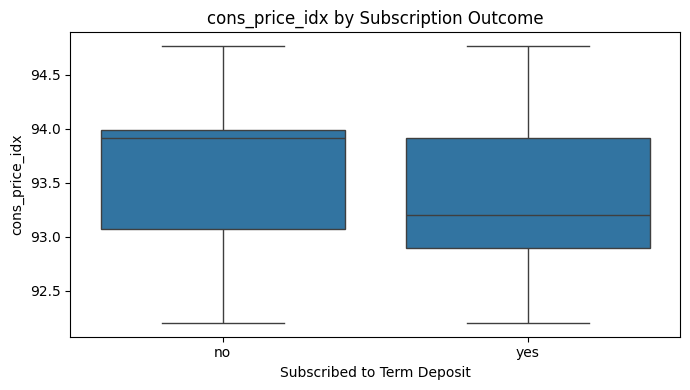

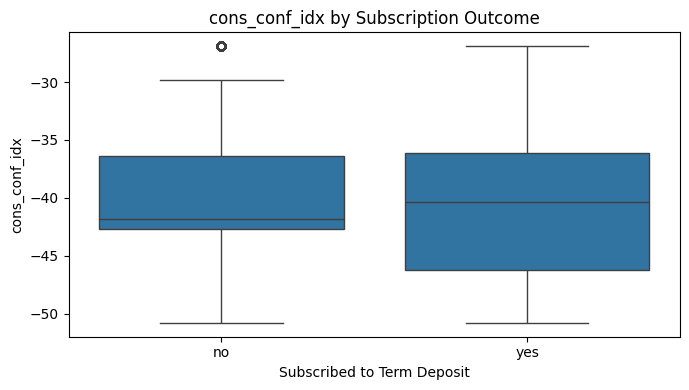

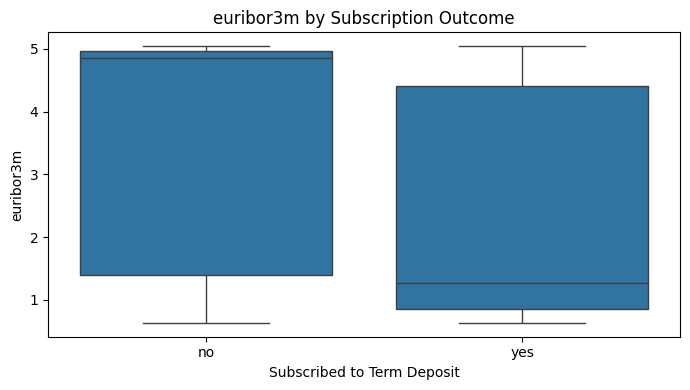

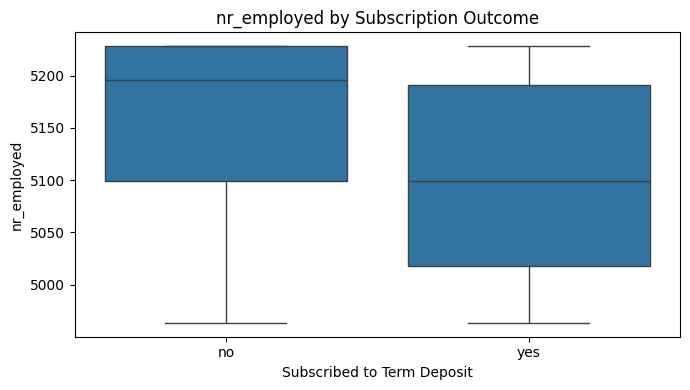

In [44]:
for feature in economic_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="y", y=feature)
    plt.title(f"{feature} by Subscription Outcome")
    plt.xlabel("Subscribed to Term Deposit")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.savefig(f"eda_{feature}_by_subscription_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

In [45]:
economic_corr = (
    df[economic_features + ["target"]]
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(ascending=False)
)

economic_corr

,target
cons_conf_idx,0.054878
cons_price_idx,-0.136211
emp_var_rate,-0.298334
euribor3m,-0.307771
nr_employed,-0.354678


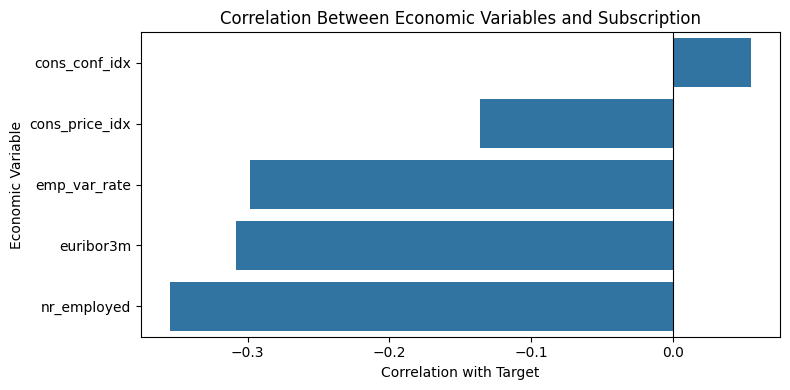

In [46]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=economic_corr.values,
    y=economic_corr.index
)
plt.title("Correlation Between Economic Variables and Subscription")
plt.xlabel("Correlation with Target")
plt.ylabel("Economic Variable")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("eda_economic_variables_correlation_with_target.png", dpi=300, bbox_inches="tight")
plt.show()

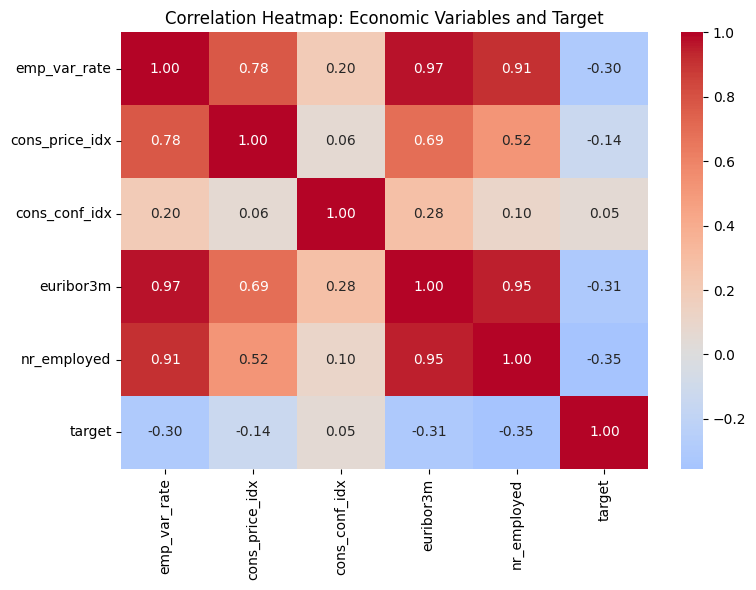

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[economic_features + ["target"]].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Heatmap: Economic Variables and Target")
plt.tight_layout()
plt.savefig("eda_economic_variables_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Economic Context Findings

Economic context variables show clear differences between subscribers and non-subscribers.

Clients who subscribed were contacted during periods with lower `emp_var_rate`, lower `euribor3m`, and lower `nr_employed` values on average. These variables also show the strongest negative correlations with the target variable.

The strongest correlations with subscription are:

* `nr_employed`: -0.355
* `euribor3m`: -0.308
* `emp_var_rate`: -0.298

This suggests that campaign success was associated with broader economic conditions. In particular, lower employment-related indicators and lower Euribor rates appear to be linked with higher subscription likelihood.

The consumer confidence index has only a weak positive correlation with subscription, while the consumer price index has a weaker negative correlation.

These variables may also help explain why some months had much higher subscription rates than others, since macroeconomic conditions change over time. However, these results should still be interpreted as associations, not direct causal effects.

During the modeling phase, these variables should be examined carefully because they may be strong predictors, but they may also be correlated with each other.


------

## Additional Client and Previous Contact Variables

This section analyzes the remaining client and campaign history variables.

The variables `default`, `housing`, and `loan` describe the client’s credit and loan status. The variable `day_of_week` describes when the last contact occurred. The variables `pdays` and `previous` describe whether and how often the client had been contacted in previous campaigns.

These variables are included to complete the exploratory analysis and identify any additional patterns associated with subscription behavior.


In [48]:
additional_categorical_features = [
    "default",
    "housing",
    "loan",
    "day_of_week"
]

for col in additional_categorical_features:
    print(f"\nSubscription rate by {col}:")
    display(subscription_rate_by_category(df, col))


Subscription rate by default:


,default,total_clients,subscribed_clients,subscription_rate
0,no,32588,4197,12.88
1,unknown,8597,443,5.15
2,yes,3,0,0.00



Subscription rate by housing:


,housing,total_clients,subscribed_clients,subscription_rate
2,yes,21576,2507,11.62
0,no,18622,2026,10.88
1,unknown,990,107,10.81



Subscription rate by loan:


,loan,total_clients,subscribed_clients,subscription_rate
0,no,33950,3850,11.34
2,yes,6248,683,10.93
1,unknown,990,107,10.81



Subscription rate by day_of_week:


,day_of_week,total_clients,subscribed_clients,subscription_rate
2,thu,8623,1045,12.12
3,tue,8090,953,11.78
4,wed,8134,949,11.67
0,fri,7827,846,10.81
1,mon,8514,847,9.95


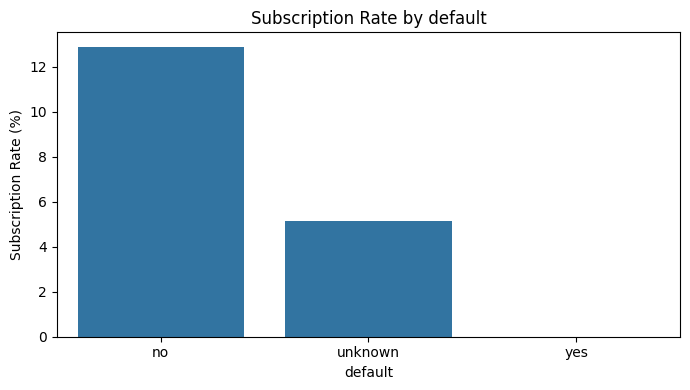

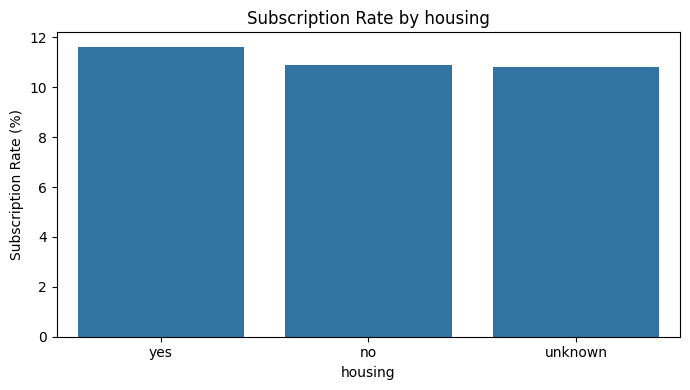

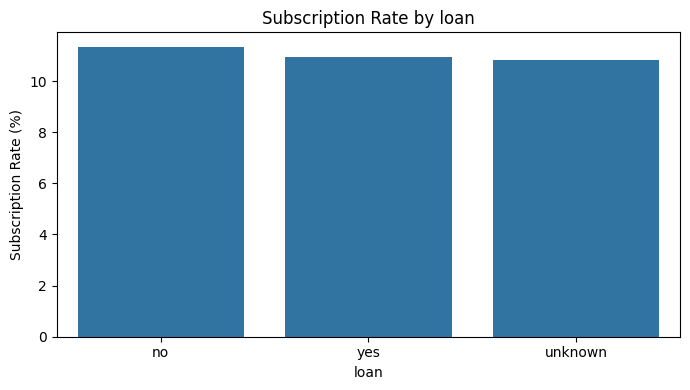

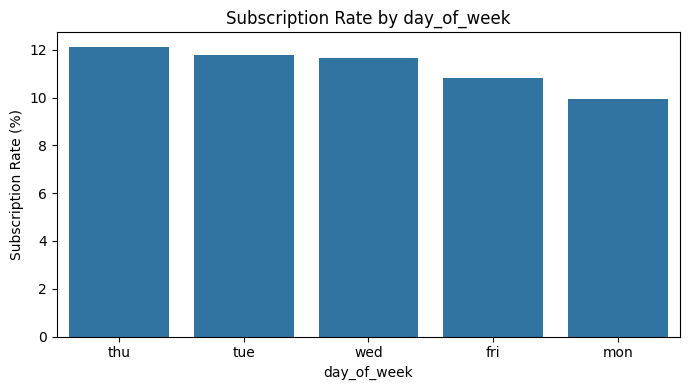

In [49]:
for col in additional_categorical_features:
    summary = subscription_rate_by_category(df, col)

    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=summary,
        x=col,
        y="subscription_rate"
    )
    plt.title(f"Subscription Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Subscription Rate (%)")
    plt.tight_layout()
    plt.savefig(f"eda_subscription_rate_by_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [50]:
df[["pdays", "previous"]].describe()

,pdays,previous
count,41188.000000,41188.000000
mean,962.475454,0.172963
std,186.910907,0.494901
min,0.000000,0.000000
25%,999.000000,0.000000
50%,999.000000,0.000000
75%,999.000000,0.000000
max,999.000000,7.000000


In [51]:
df["previously_contacted"] = np.where(df["pdays"] == 999, "No", "Yes")

previously_contacted_subscription = subscription_rate_by_category(
    df,
    "previously_contacted"
)

previously_contacted_subscription

,previously_contacted,total_clients,subscribed_clients,subscription_rate
1,Yes,1515,967,63.83
0,No,39673,3673,9.26


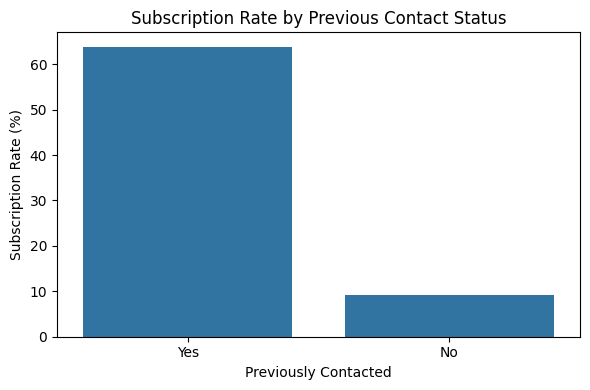

In [52]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=previously_contacted_subscription,
    x="previously_contacted",
    y="subscription_rate"
)
plt.title("Subscription Rate by Previous Contact Status")
plt.xlabel("Previously Contacted")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_previous_contact_status.png", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
df["previous_group"] = pd.cut(
    df["previous"],
    bins=[-1, 0, 1, 2, 5, df["previous"].max()],
    labels=["0", "1", "2", "3-5", "6+"]
)

previous_subscription = subscription_rate_by_category(df, "previous_group")
previous_subscription

/tmp/ipykernel_926/904224103.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(column)


,previous_group,total_clients,subscribed_clients,subscription_rate
3,3-5,304,179,58.88
4,6+,6,3,50.00
2,2,754,350,46.42
1,1,4561,967,21.20
0,0,35563,3141,8.83


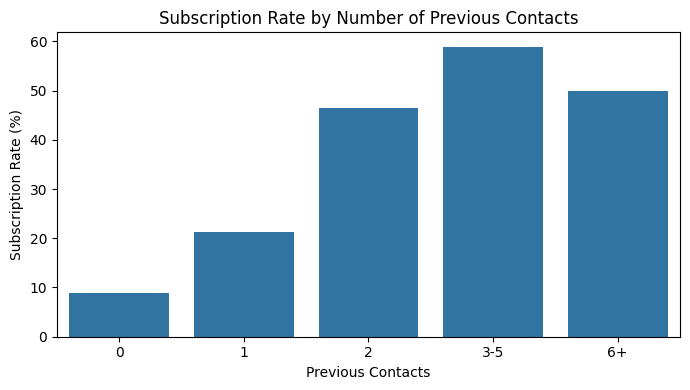

In [54]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=previous_subscription.sort_values("previous_group"),
    x="previous_group",
    y="subscription_rate"
)
plt.title("Subscription Rate by Number of Previous Contacts")
plt.xlabel("Previous Contacts")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_previous_group.png", dpi=300, bbox_inches="tight")
plt.show()

### Additional Client and Contact Variable Findings

The remaining client and contact variables show more moderate differences in subscription rates.

For `default`, clients with `default = no` have a higher subscription rate than clients with `default = unknown`. The `default = yes` category contains only 3 clients, so it should not be interpreted as a reliable pattern.

The `housing` and `loan` variables show only small differences in subscription rates. Clients with and without housing loans or personal loans have similar subscription rates, suggesting that these variables may be weaker predictors compared with previous campaign history, contact duration, economic variables, and campaign timing.

The `day_of_week` variable also shows relatively small differences. Thursday has the highest subscription rate, while Monday has the lowest, but the variation is not large compared with stronger variables such as `poutcome`, `previously_contacted`, `duration`, and economic indicators.

Overall, these variables complete the exploratory analysis, but they appear to provide weaker standalone business signals than the main variables identified earlier.


### Previous Contact Findings

The variable `pdays` has a special value: `999`, which means the client was not previously contacted. Because most clients have `pdays = 999`, it is more useful to create a clearer variable called `previously_contacted`.

Clients who were previously contacted have a much higher subscription rate than clients who were not previously contacted:

* previously contacted: 63.83%
* not previously contacted: 9.26%

The number of previous contacts also shows a strong relationship with subscription. Clients with zero previous contacts have a subscription rate of only 8.83%, while clients with one or more previous contacts show much higher subscription rates.

This suggests that previous campaign engagement is strongly associated with future subscription behavior. However, this should be interpreted together with `poutcome`, because both variables describe previous campaign history and may carry overlapping information.


------

## EDA Summary

The exploratory analysis identified several patterns associated with term deposit subscription.

The dataset is strongly imbalanced, with only 11.27% of clients subscribing. This means that accuracy alone will not be sufficient for model evaluation.

Client profile variables show meaningful differences in subscription behavior. Students, retired clients, younger clients, and older clients show higher subscription rates than the main working-age population.

Campaign-related variables also show strong patterns. Cellular contact is associated with higher subscription rates than telephone contact. Subscription rates vary strongly by month, with March, December, September, and October showing the highest rates.

Previous campaign history is one of the strongest signals. Clients with a previous successful campaign outcome, previous contact history, or multiple previous contacts show much higher subscription rates.

Contact duration has the strongest apparent relationship with subscription. Longer calls are much more likely to result in subscription. However, `duration` is a data leakage risk because it is only known after the call takes place. Therefore, it should be excluded from the realistic pre-campaign targeting model.

Economic context variables are also associated with subscription. Lower `nr_employed`, lower `euribor3m`, and lower `emp_var_rate` values are linked with higher subscription likelihood.

Overall, the strongest candidate predictors identified during EDA are:

* `duration`
* `poutcome`
* `previously_contacted`
* `previous`
* `euribor3m`
* `nr_employed`
* `emp_var_rate`
* `contact`
* `month`
* `age`
* `job`

The next step is to build classification models and compare two approaches:

1. a model including `duration`, used as a performance upper bound
2. a realistic model excluding `duration`, used for pre-campaign client targeting
